In [8]:
from google.colab import files

uploaded = files.upload()

Saving dataset.csv to dataset (2).csv


In [9]:
!pip install pandas numpy matplotlib seaborn wordcloud scikit-learn nltk

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
import re
import string

from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

nltk.download('stopwords')

from nltk.corpus import stopwords

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [11]:
df = pd.read_csv('dataset.csv')

df.head()

,2401,Borderlands,Positive,"im getting on borderlands and i will murder you all ,"
0,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
1,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
2,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
3,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
4,2401,Borderlands,Positive,im getting into borderlands and i can murder y...


In [15]:
import pandas as pd

df = pd.read_csv('dataset.csv', header=None)

df.head()

,0,1,2,3
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [16]:
df.columns = ['ID', 'Topic', 'Sentiment', 'Review']

df.head()

,ID,Topic,Sentiment,Review
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [17]:
print("Dataset Shape:")
print(df.shape)

print("\nDataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nSentiment Counts:")
print(df['Sentiment'].value_counts())

Dataset Shape:
(74682, 4)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74682 entries, 0 to 74681
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   ID         74682 non-null  int64 
 1   Topic      74682 non-null  object
 2   Sentiment  74682 non-null  object
 3   Review     73996 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.3+ MB
None

Missing Values:
ID             0
Topic          0
Sentiment      0
Review       686
dtype: int64

Sentiment Counts:
Sentiment
Negative      22542
Positive      20832
Neutral       18318
Irrelevant    12990
Name: count, dtype: int64


In [18]:
df.dropna(inplace=True)

In [19]:
df.drop_duplicates(inplace=True)

In [20]:
df['Review'] = df['Review'].str.lower()

In [21]:
def clean_text(text):

    text = re.sub(r"http\S+", "", text)

    text = re.sub(r"[^a-zA-Z\s]", "", text)

    stop_words = stopwords.words('english')

    words = text.split()

    words = [word for word in words if word not in stop_words]

    return " ".join(words)

df['Cleaned_Review'] = df['Review'].apply(clean_text)

df.head()

,ID,Topic,Sentiment,Review,Cleaned_Review
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...,im getting borderlands murder
1,2401,Borderlands,Positive,i am coming to the borders and i will kill you...,coming borders kill
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...,im getting borderlands kill
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...,im coming borderlands murder
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...,im getting borderlands murder


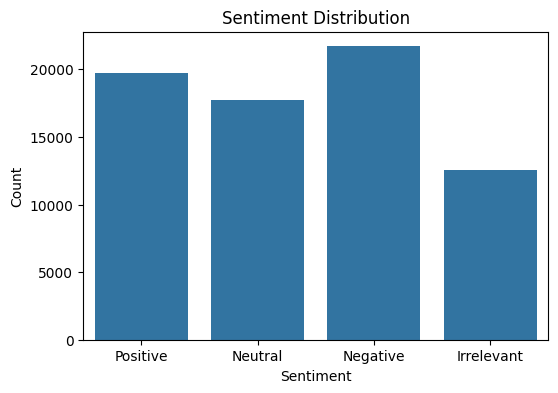

In [22]:
plt.figure(figsize=(6,4))

sns.countplot(x='Sentiment', data=df)

plt.title("Sentiment Distribution")

plt.xlabel("Sentiment")

plt.ylabel("Count")

plt.savefig("sentiment_distribution.png")

plt.show()

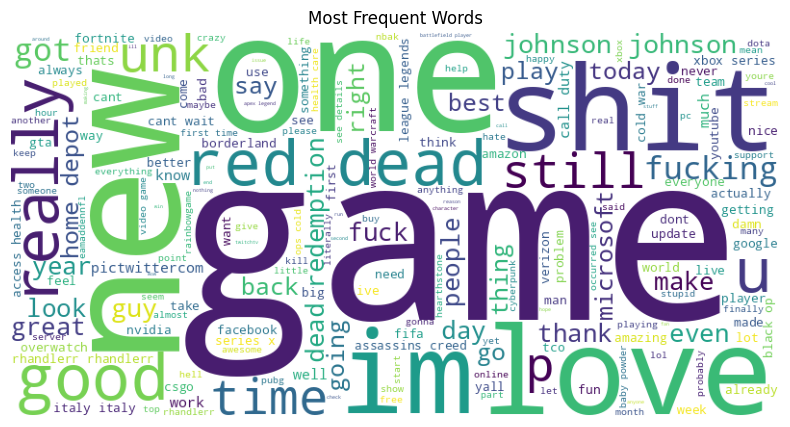

In [23]:
text = " ".join(df['Cleaned_Review'])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(text)

plt.figure(figsize=(10,5))

plt.imshow(wordcloud)

plt.axis('off')

plt.title("Most Frequent Words")

plt.savefig("wordcloud_visualization.png")

plt.show()

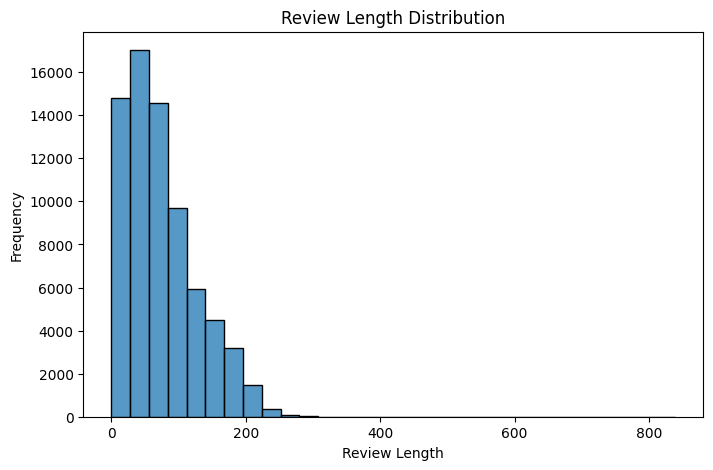

In [24]:
df['Review_Length'] = df['Cleaned_Review'].apply(len)

plt.figure(figsize=(8,5))

sns.histplot(df['Review_Length'], bins=30)

plt.title("Review Length Distribution")

plt.xlabel("Review Length")

plt.ylabel("Frequency")

plt.savefig("review_length_distribution.png")

plt.show()

In [25]:
vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(df['Cleaned_Review'])

y = df['Sentiment']

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [27]:
model = LogisticRegression()

model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [28]:
y_pred = model.predict(X_test)

In [29]:
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

print("\nClassification Report:\n")

print(classification_report(y_test, y_pred))

Model Accuracy: 0.7720326564789617

Classification Report:

              precision    recall  f1-score   support

  Irrelevant       0.82      0.64      0.72      2505
    Negative       0.80      0.83      0.82      4405
     Neutral       0.73      0.76      0.74      3541
    Positive       0.76      0.79      0.78      3880

    accuracy                           0.77     14331
   macro avg       0.78      0.76      0.76     14331
weighted avg       0.77      0.77      0.77     14331



In [30]:
sample_review = ["This product is excellent and amazing"]

sample_vector = vectorizer.transform(sample_review)

prediction = model.predict(sample_vector)

print("Predicted Sentiment:", prediction[0])

Predicted Sentiment: Positive


In [31]:
from google.colab import files

files.download('sentiment_distribution.png')
files.download('wordcloud_visualization.png')
files.download('review_length_distribution.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [32]:
import pickle

pickle.dump(model, open('sentiment_model.pkl', 'wb'))

pickle.dump(vectorizer, open('vectorizer.pkl', 'wb'))

In [33]:
files.download('sentiment_model.pkl')

files.download('vectorizer.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>